# WATER POTABILITY

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE 
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [4]:
df=pd.read_csv('Watera.csv')
df

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,614.26,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,387.89,3.93,313.10,153.36,9.92,20.69,2.07,0
2,6.29,133.09,225.55,1.46,332.04,1420.43,8.76,32.87,5.05,0
3,7.39,71.89,459.23,0.56,609.63,24142.89,9.62,42.80,2.26,0
4,6.31,273.01,308.99,0.64,52.59,196.85,1.05,133.38,5.30,0
...,...,...,...,...,...,...,...,...,...,...
99995,5.41,257.02,707.62,0.04,146.47,222.71,7.67,103.63,2.88,0
99996,8.43,360.25,NaN,3.07,267.58,1708.79,0.57,154.33,2.40,0
99997,5.79,429.42,182.79,3.44,60.56,1017.59,6.38,115.63,1.61,0
99998,7.03,95.45,285.10,3.76,722.35,2614.20,10.85,116.46,2.23,0


# PREPROCESSING

In [3]:
df.shape

(100000, 10)

In [4]:
df.dtypes

ph                 float64
hardness           float64
tds                float64
chlorine           float64
sulfate            float64
conductivity       float64
organic_carbon     float64
trihalomethanes    float64
turbidity          float64
potability           int64
dtype: object

In [5]:
df.isna().sum()

ph                 3121
hardness              0
tds                2384
chlorine              0
sulfate             813
conductivity       1598
organic_carbon        0
trihalomethanes       0
turbidity             0
potability            0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ph               100000 non-null  float64
 1   hardness         100000 non-null  float64
 2   tds              100000 non-null  float64
 3   chlorine         100000 non-null  float64
 4   sulfate          100000 non-null  float64
 5   conductivity     100000 non-null  float64
 6   organic_carbon   100000 non-null  float64
 7   trihalomethanes  100000 non-null  float64
 8   turbidity        100000 non-null  float64
 9   potability       100000 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 7.6 MB


In [9]:
df.describe()

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,7.249216,309.214750,328.788350,2.500058,252.830514,1999.029623,7.198689,72.739011,3.139499,0.076160
std,0.979959,222.321384,243.258211,1.616047,152.339570,3996.970819,3.507656,50.389586,2.417457,0.265255
min,5.000000,0.000000,0.030000,0.000000,0.000000,0.040000,0.000000,0.000000,0.000000,0.000000
25%,6.520000,151.540000,163.197500,1.230000,138.730000,726.235000,4.710000,29.997500,1.450000,0.000000
50%,7.240000,271.080000,270.155000,2.410000,237.050000,1438.565000,7.300000,68.010000,2.660000,0.000000
75%,7.950000,391.580000,375.820000,3.570000,335.712500,2151.095000,9.840000,105.700000,4.300000,0.000000
max,9.990000,1099.990000,1099.990000,8.990000,799.970000,39961.990000,17.990000,229.960000,13.990000,1.000000


# Filling missing value

In [5]:
lst = ['ph', 'tds', 'sulfate', 'conductivity']
df[lst] = df[lst].fillna(df[lst].median())

In [50]:
df.isna().sum()

ph                 0
hardness           0
tds                0
chlorine           0
sulfate            0
conductivity       0
organic_carbon     0
trihalomethanes    0
turbidity          0
potability         0
dtype: int64

# EDA

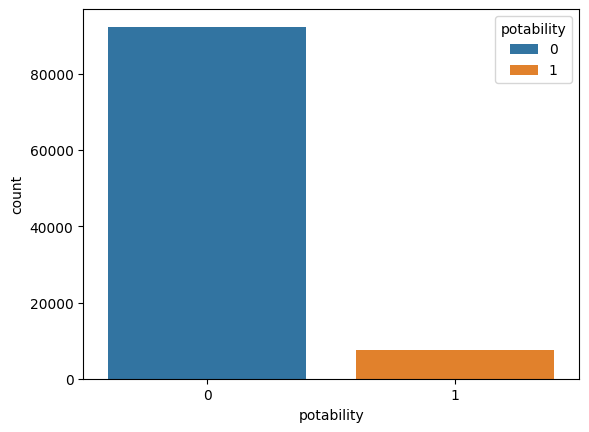

In [10]:
sns.countplot(data=df,x='potability',hue='potability')
plt.show()

In [11]:
df.potability.value_counts()

potability
0    92384
1     7616
Name: count, dtype: int64

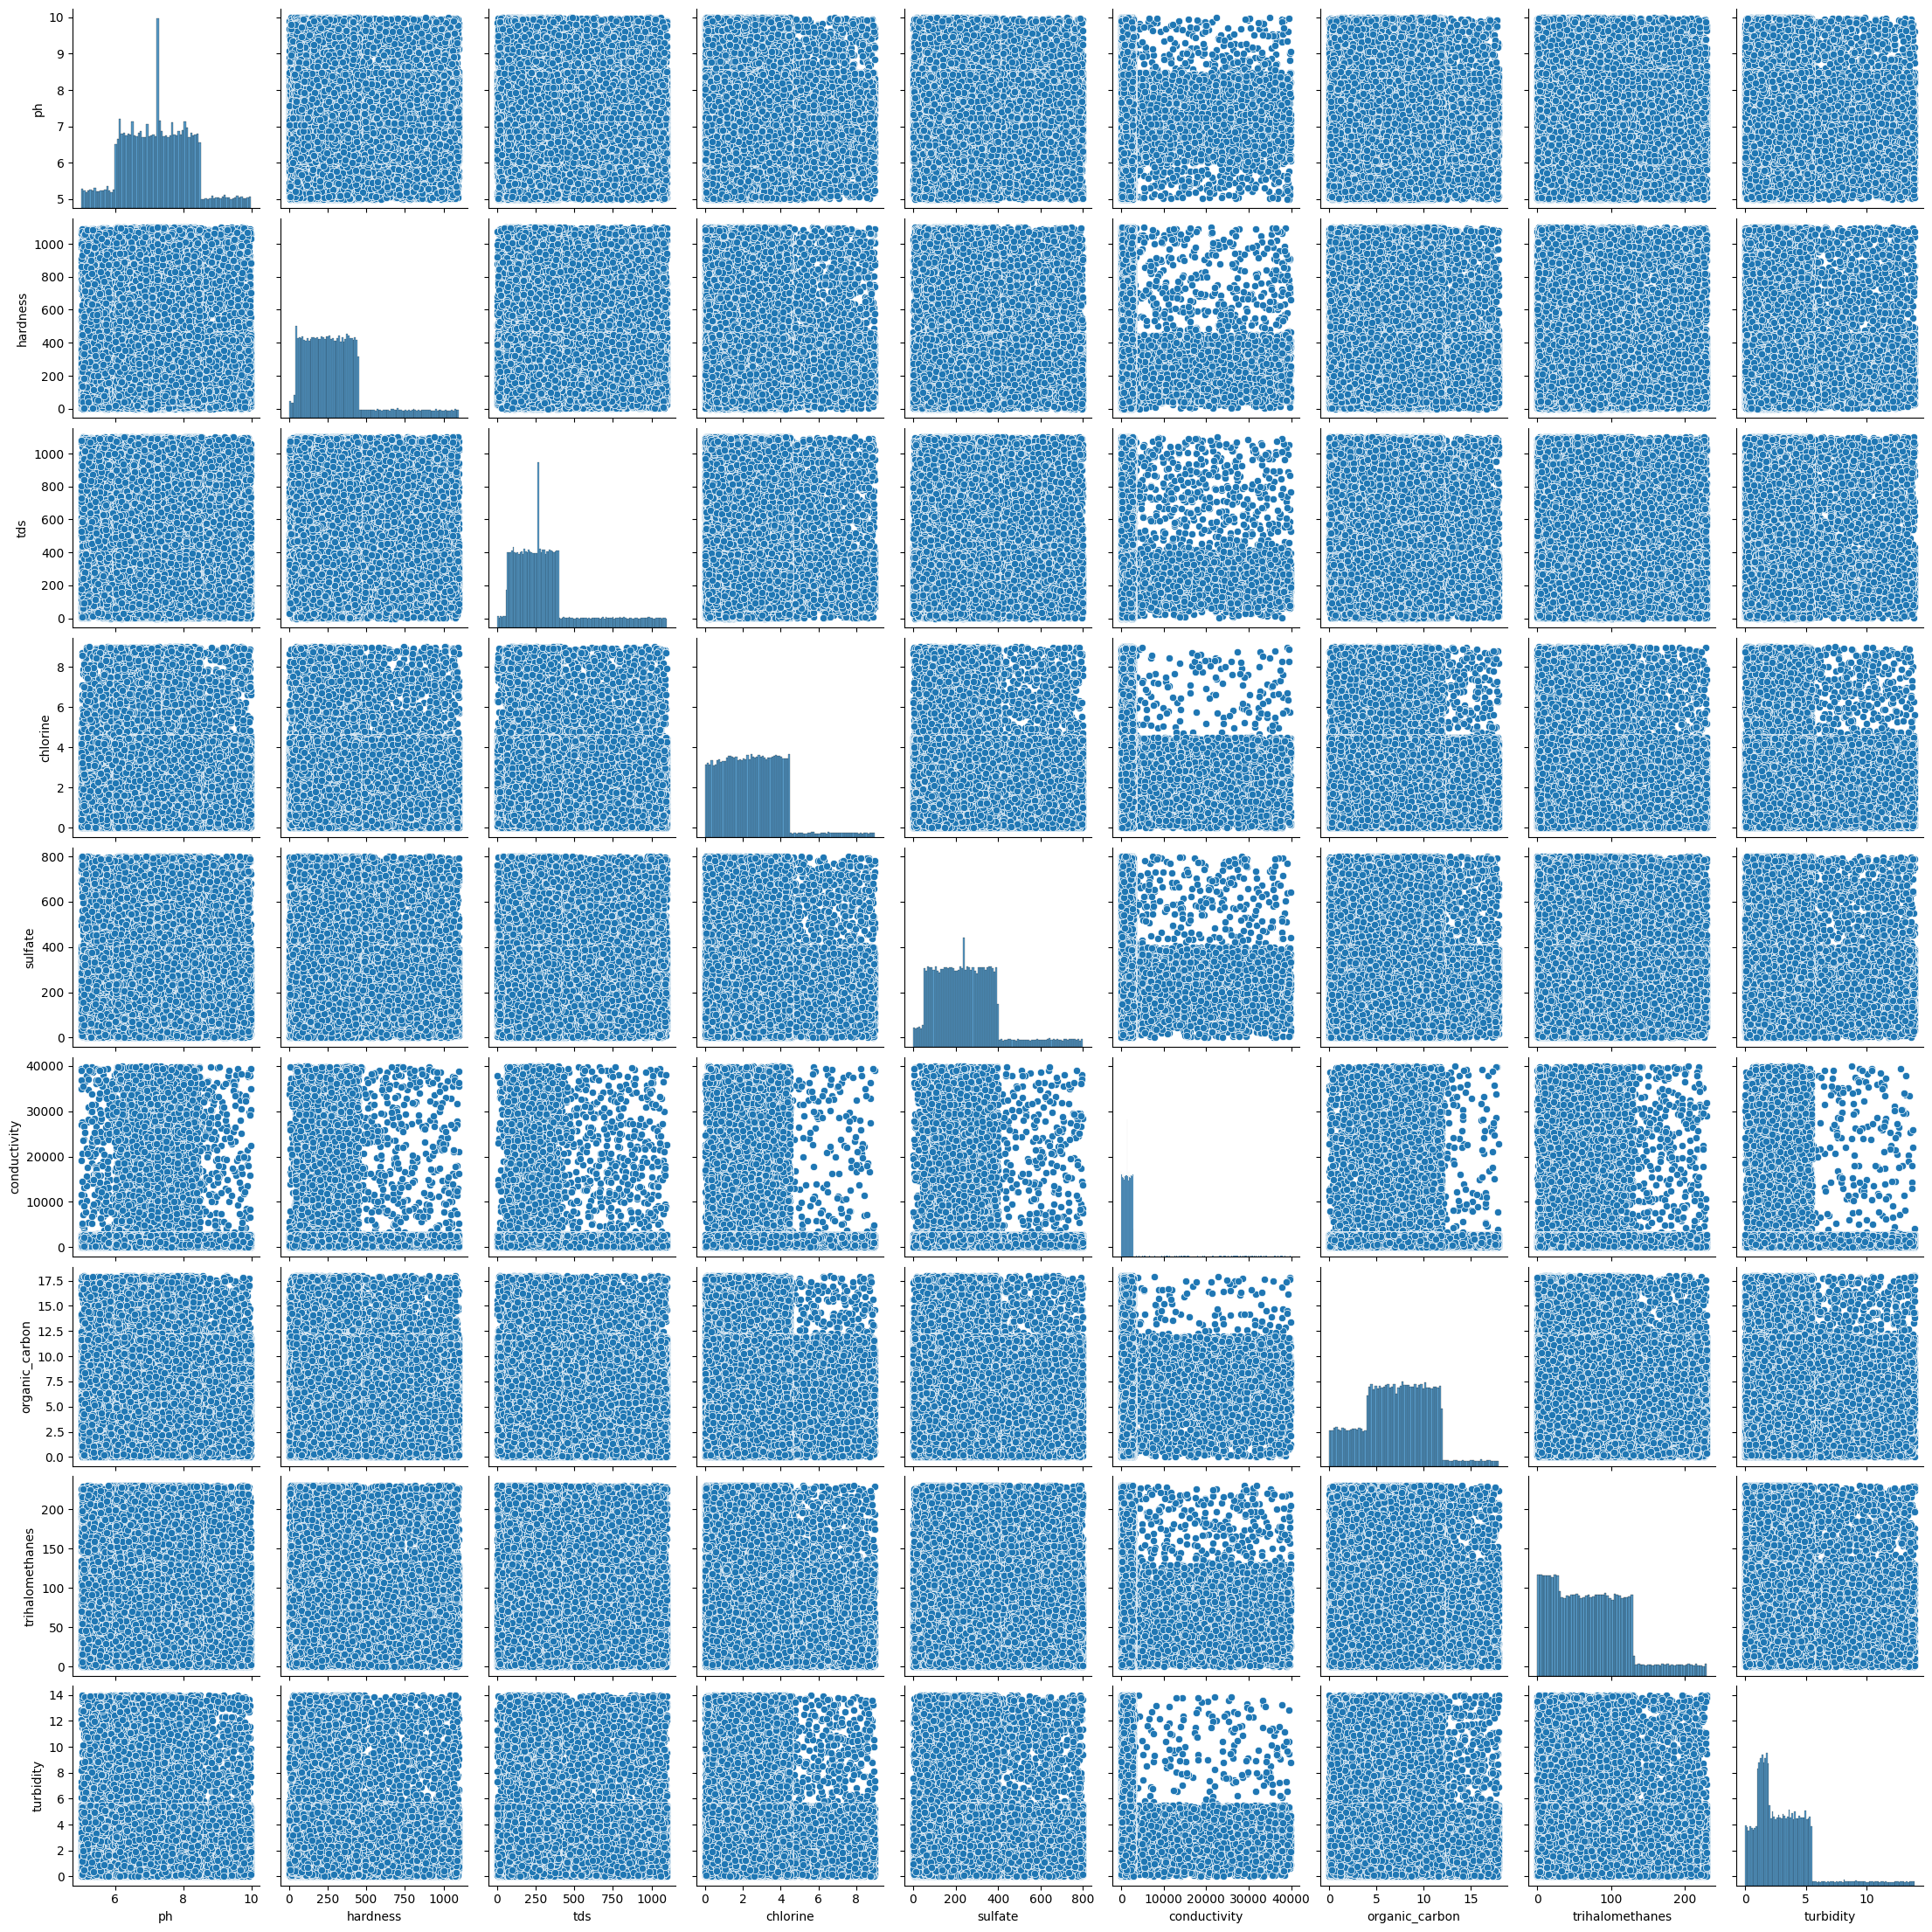

In [13]:
cols=['ph', 'hardness', 'tds', 'chlorine', 'sulfate', 'conductivity',
       'organic_carbon', 'trihalomethanes', 'turbidity']
sns.pairplot(df[cols])

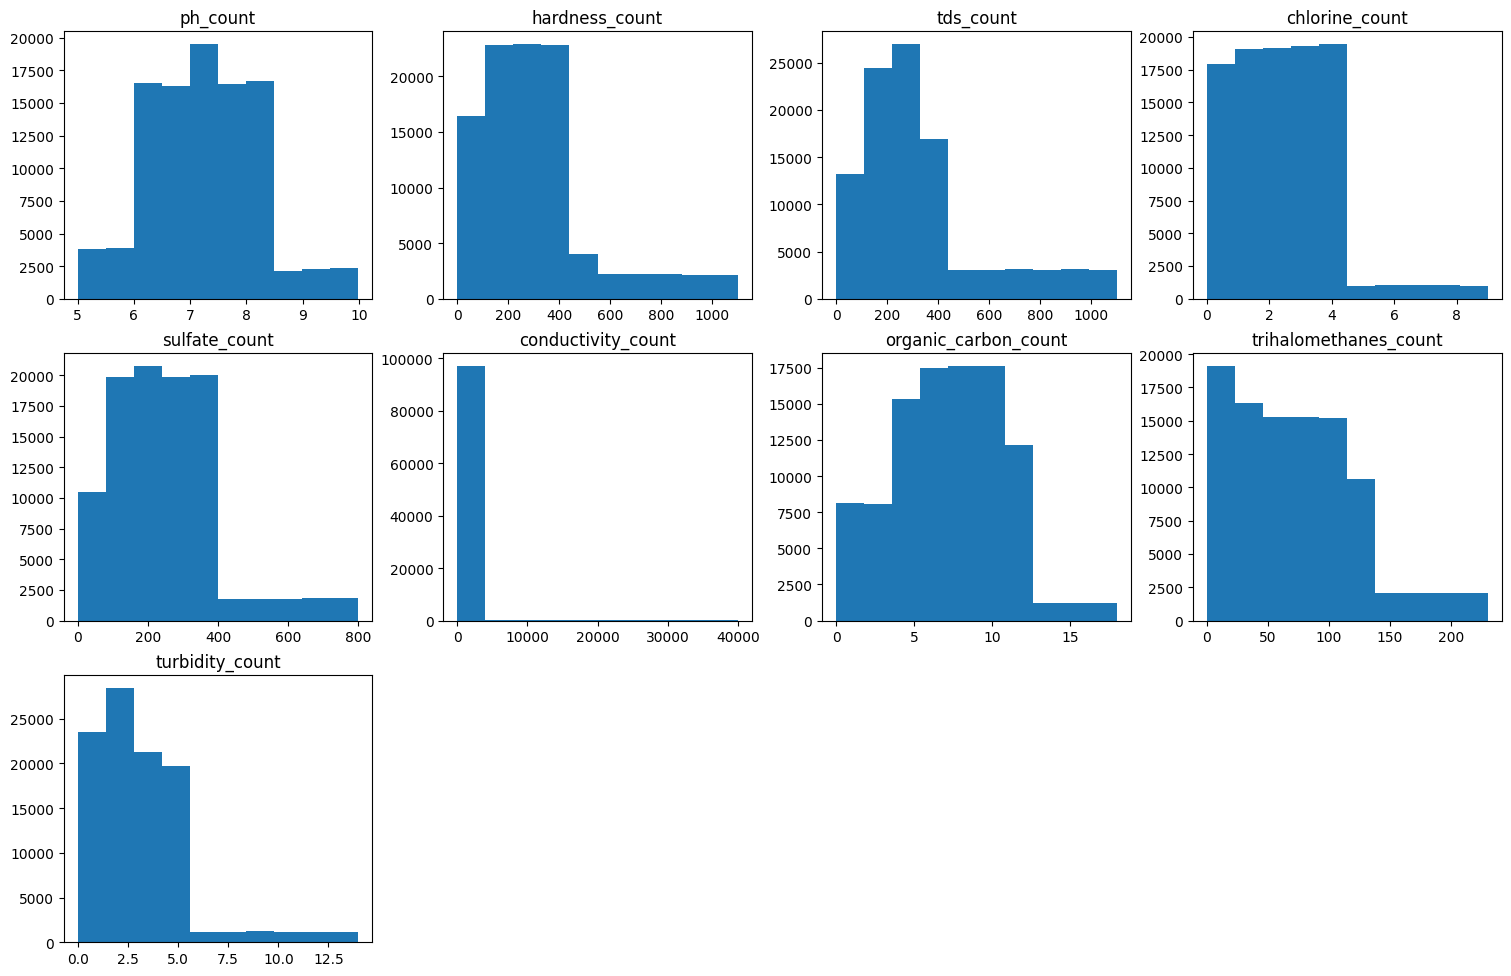

In [14]:
plt.figure(figsize=(15,15),layout='constrained')
for i in range(len(cols)):
    plt.subplot(5,4,i+1)
    plt.hist(data=df,x=cols[i])
    plt.title(cols[i]+'_count')
plt.show()

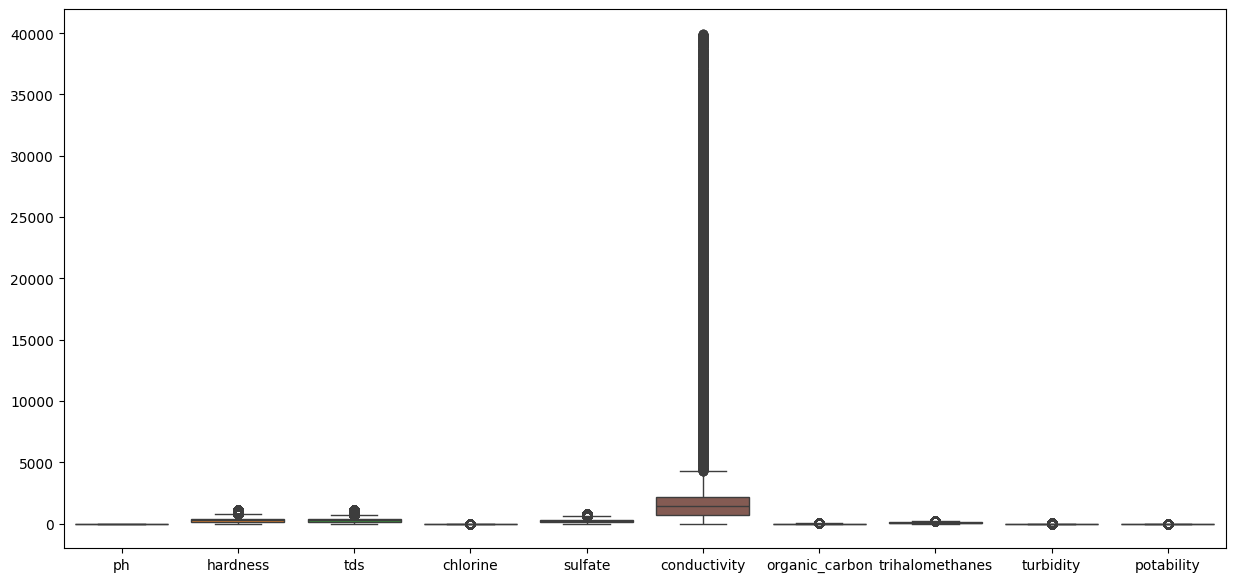

In [61]:
plt.figure(figsize=(15,7))
sns.boxplot(df)
plt.show()

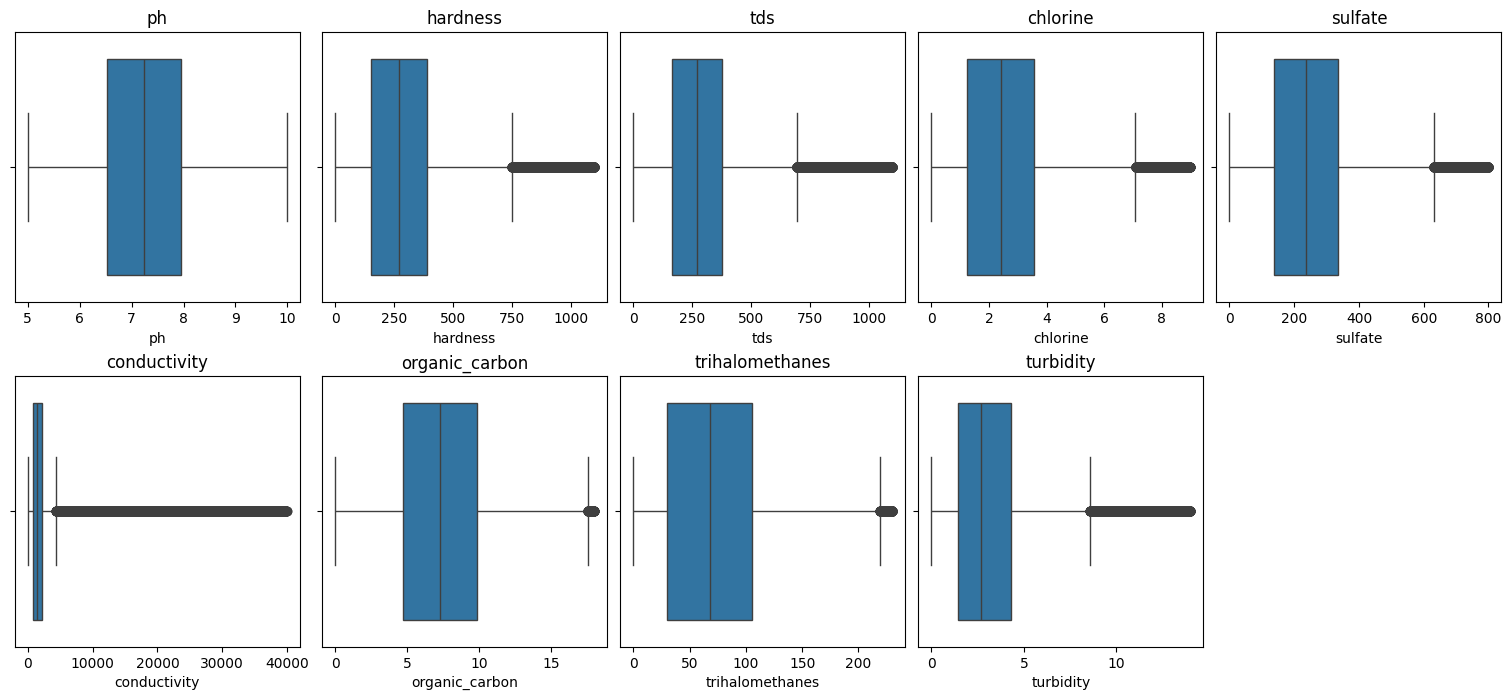

In [16]:
plt.figure(figsize=(15,15),layout='constrained')
for i in range(len(cols)):
    plt.subplot(5,5,i+1)
    sns.boxplot(data=df,x=cols[i])
    plt.title(cols[i])
plt.show()

In [6]:
data=df.copy()

# Outliers treating

In [18]:
outlier_count = {}
outlier_col=['hardness','tds','chlorine','sulfate','conductivity','organic_carbon','trihalomethanes', 'turbidity']
for col in outlier_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_count[col] = count

outlier_count

{'hardness': np.int64(6855),
 'tds': np.int64(11371),
 'chlorine': np.int64(2108),
 'sulfate': np.int64(3867),
 'conductivity': np.int64(2843),
 'organic_carbon': np.int64(292),
 'trihalomethanes': np.int64(925),
 'turbidity': np.int64(4456)}

<Axes: >

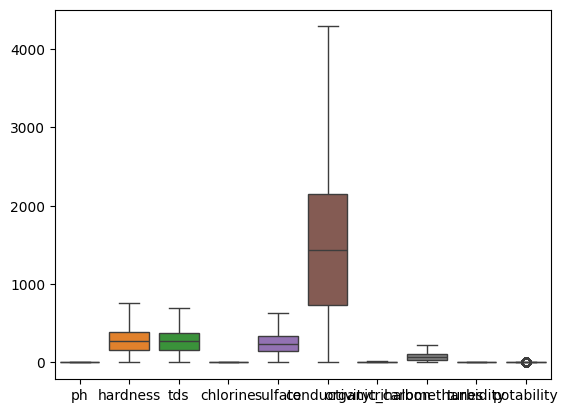

In [5]:
lst=['hardness','tds','chlorine','sulfate','conductivity','organic_carbon','trihalomethanes', 'turbidity']
for i in lst:
  Q1=data[i].quantile(0.25)
  Q3=data[i].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR
    
  data.loc[(data[i]>upper_limit),i]=upper_limit
  data.loc[(data[i]<lower_limit),i]=lower_limit
sns.boxplot(data)

In [63]:
correlation=data.corr()
correlation

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
ph,1.000000,-0.000678,0.004877,0.000035,-0.000974,0.002006,-0.003456,0.004796,-0.000586,-0.002400
hardness,-0.000678,1.000000,0.002526,0.003178,0.002445,0.000462,-0.000747,0.000028,-0.001207,-0.108194
tds,0.004877,0.002526,1.000000,-0.001124,0.000360,-0.003409,-0.001516,-0.000785,-0.002888,-0.150573
chlorine,0.000035,0.003178,-0.001124,1.000000,0.004724,0.004806,-0.001859,-0.003061,0.000863,-0.086587
sulfate,-0.000974,0.002445,0.000360,0.004724,1.000000,-0.008147,0.006494,0.005657,-0.003412,-0.104841
conductivity,0.002006,0.000462,-0.003409,0.004806,-0.008147,1.000000,-0.010300,0.003614,0.000908,-0.170305
organic_carbon,-0.003456,-0.000747,-0.001516,-0.001859,0.006494,-0.010300,1.000000,-0.007613,-0.000990,-0.109116
trihalomethanes,0.004796,0.000028,-0.000785,-0.003061,0.005657,0.003614,-0.007613,1.000000,-0.006975,-0.143091
turbidity,-0.000586,-0.001207,-0.002888,0.000863,-0.003412,0.000908,-0.000990,-0.006975,1.000000,-0.086028
potability,-0.002400,-0.108194,-0.150573,-0.086587,-0.104841,-0.170305,-0.109116,-0.143091,-0.086028,1.000000


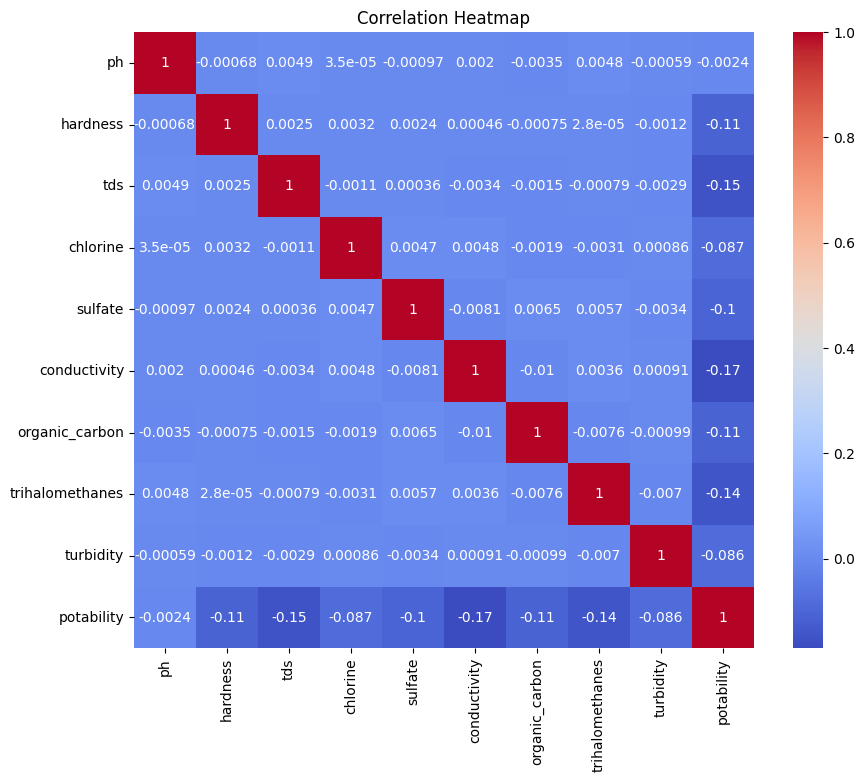

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation,cmap='coolwarm',annot=True)
plt.title('Correlation Heatmap')
plt.show()

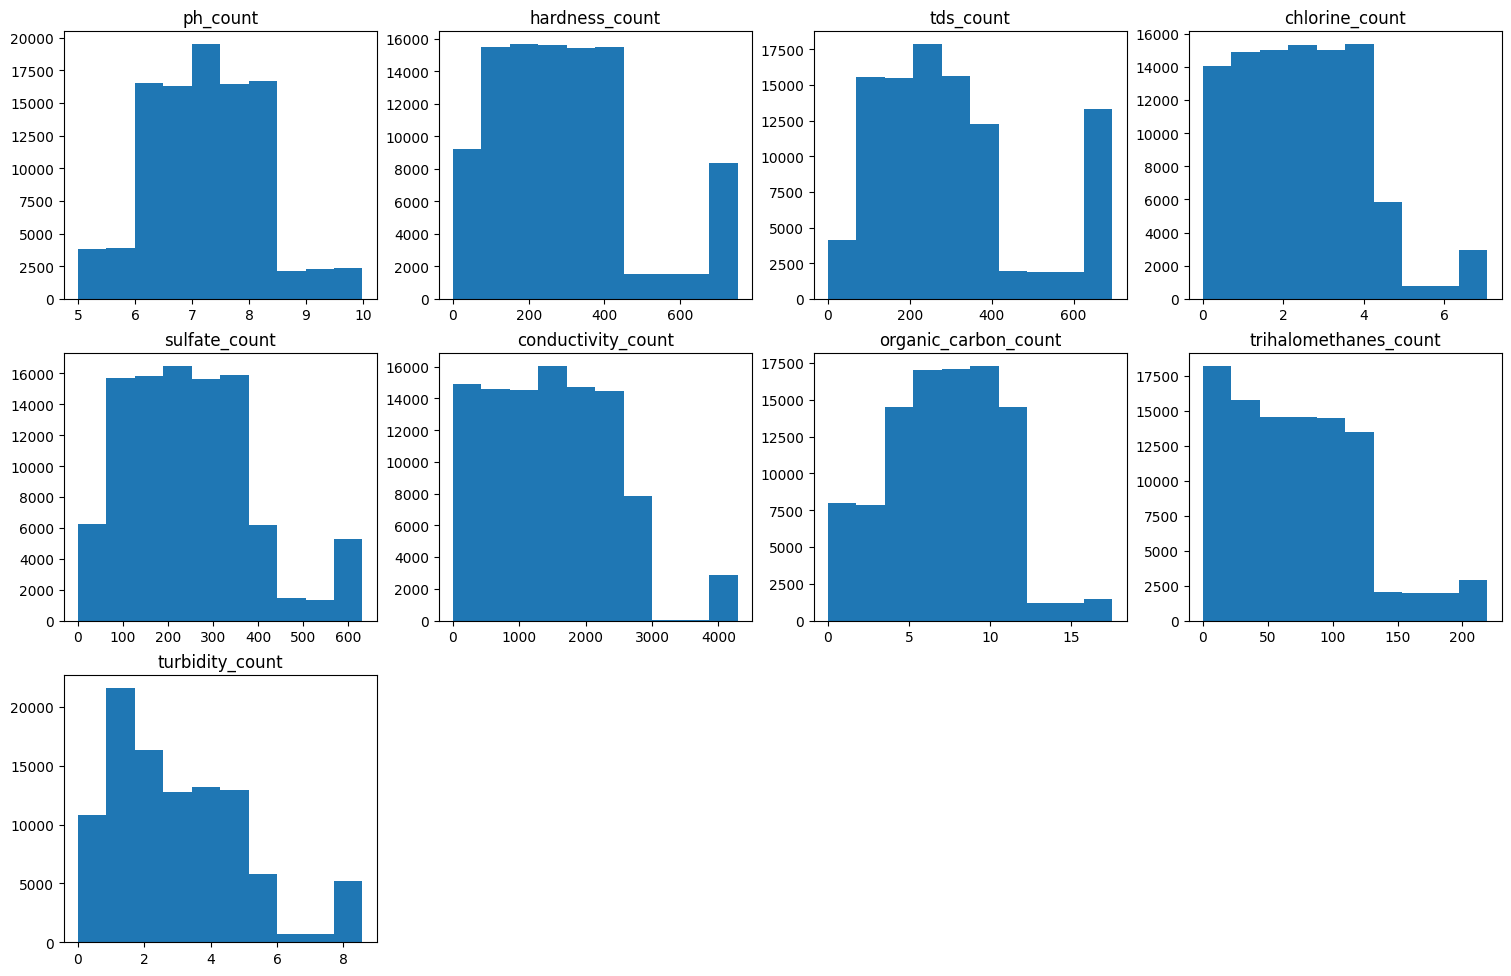

In [23]:
plt.figure(figsize=(15,15),layout='constrained')
for i in range(len(cols)):
    plt.subplot(5,4,i+1)
    plt.hist(data=data,x=cols[i])
    plt.title(cols[i]+'_count')
plt.show()

# Data splitting

In [6]:
x=data.drop('potability',axis=1)
x

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,7.14,440.98,614.26000,2.12,208.39000,350.920,7.22,17.32,2.23
1,6.41,242.82,387.89000,3.93,313.10000,153.360,9.92,20.69,2.07
2,6.29,133.09,225.55000,1.46,332.04000,1420.430,8.76,32.87,5.05
3,7.39,71.89,459.23000,0.56,609.63000,4288.385,9.62,42.80,2.26
4,6.31,273.01,308.99000,0.64,52.59000,196.850,1.05,133.38,5.30
...,...,...,...,...,...,...,...,...,...
99995,5.41,257.02,694.75375,0.04,146.47000,222.710,7.67,103.63,2.88
99996,8.43,360.25,270.15500,3.07,267.58000,1708.790,0.57,154.33,2.40
99997,5.79,429.42,182.79000,3.44,60.56000,1017.590,6.38,115.63,1.61
99998,7.03,95.45,285.10000,3.76,631.18625,2614.200,10.85,116.46,2.23


In [7]:
y=data['potability']
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: potability, Length: 100000, dtype: int64

# Train Test Split

In [8]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

# Scaling

In [10]:
sc=StandardScaler()
xtrain=sc.fit_transform(xtrain)
xtest=sc.transform(xtest)

# Logistic regression

In [100]:
logi=LogisticRegression()
logi.fit(xtrain,ytrain)
ypred=logi.predict(xtest)

Test acc: 0.9249
Train acc: 0.92225
Classification report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96     18524
           1       0.47      0.12      0.19      1476

    accuracy                           0.92     20000
   macro avg       0.70      0.56      0.58     20000
weighted avg       0.90      0.92      0.90     20000

Confusion matrix:
 [[18319   205]
 [ 1297   179]]


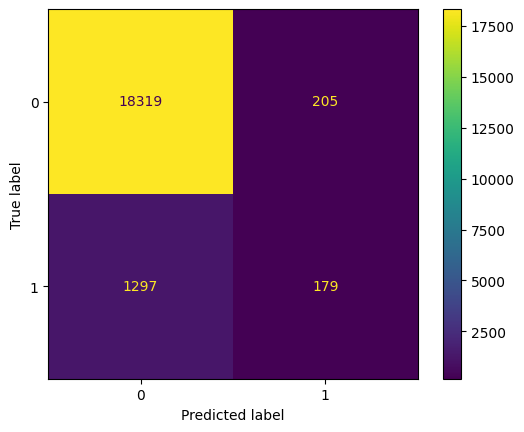

In [101]:
print('Test acc:',logi.score(xtest,ytest))
print('Train acc:',logi.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [102]:
logi_acc=accuracy_score(ytest,ypred)
print('accuracy_score',logi_acc)

accuracy_score 0.9249


# Decision tree

In [96]:
dt=DecisionTreeClassifier(max_depth=7)
dt.fit(xtrain,ytrain)
ypred=dt.predict(xtest)

Test acc: 0.95495
Train acc: 0.9555125
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98     18524
           1       0.62      1.00      0.77      1476

    accuracy                           0.95     20000
   macro avg       0.81      0.97      0.87     20000
weighted avg       0.97      0.95      0.96     20000

Confusion matrix:
 [[17626   898]
 [    3  1473]]


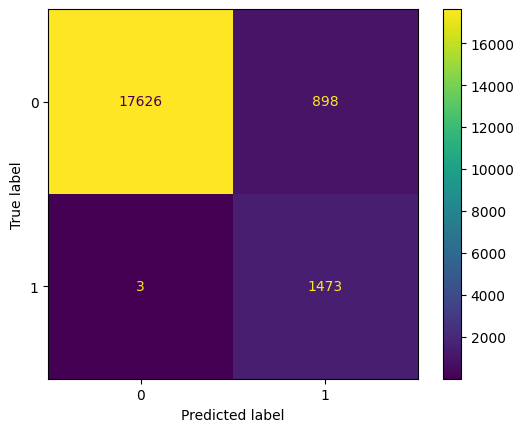

In [97]:
print('Test acc:',dt.score(xtest,ytest))
print('Train acc:',dt.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [98]:
dt_acc=accuracy_score(ytest,ypred)
print('accuracy_score',dt_acc)

accuracy_score 0.95495


# RANDOM FOREST

In [104]:
rf=RandomForestClassifier(n_estimators=10,random_state=20)
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)

Test acc: 0.9972
Train acc: 0.999875
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.97      0.99      0.98      1476

    accuracy                           1.00     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

Confusion matrix:
 [[18480    44]
 [   12  1464]]


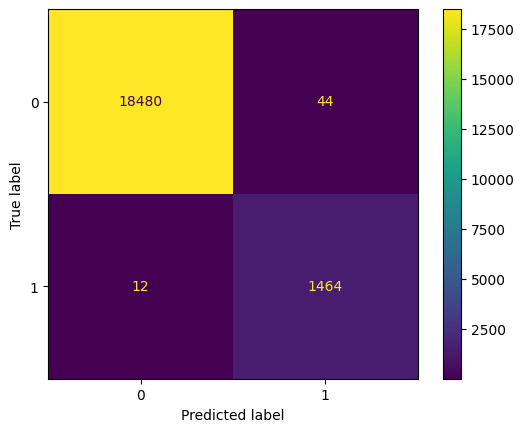

In [105]:
print('Test acc:',rf.score(xtest,ytest))
print('Train acc:',rf.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [106]:
rf_acc=accuracy_score(ytest,ypred)
print('accuracy_score',rf_acc)

accuracy_score 0.9972


# ADA BOOST

In [77]:
ada=AdaBoostClassifier(n_estimators=300,learning_rate=0.5,random_state=10)
ada.fit(xtrain,ytrain)
ypred=ada.predict(xtest)

Test acc: 0.9881
Train acc: 0.9879125
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     18524
           1       0.86      1.00      0.93      1476

    accuracy                           0.99     20000
   macro avg       0.93      0.99      0.96     20000
weighted avg       0.99      0.99      0.99     20000

Confusion matrix:
 [[18286   238]
 [    0  1476]]


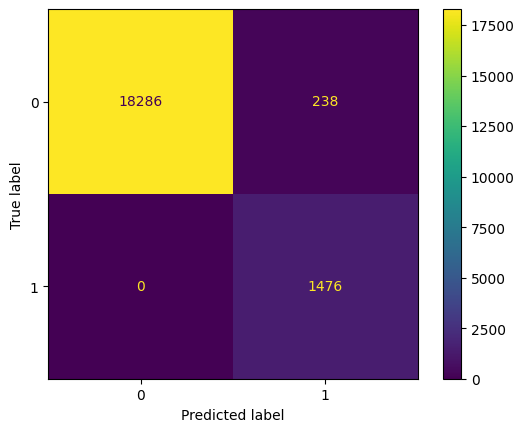

In [78]:
print('Test acc:',ada.score(xtest,ytest))
print('Train acc:',ada.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [79]:
ada_acc=accuracy_score(ytest,ypred)
print('accuracy_score',ada_acc)

accuracy_score 0.9881


# GRADIENT BOOST

In [70]:
gb=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,random_state=8)
gb.fit(xtrain,ytrain)
ypred=gb.predict(xtest)

Test acc: 0.99535
Train acc: 0.995775
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.95      0.99      0.97      1476

    accuracy                           1.00     20000
   macro avg       0.97      0.99      0.98     20000
weighted avg       1.00      1.00      1.00     20000

Confusion matrix:
 [[18440    84]
 [    9  1467]]


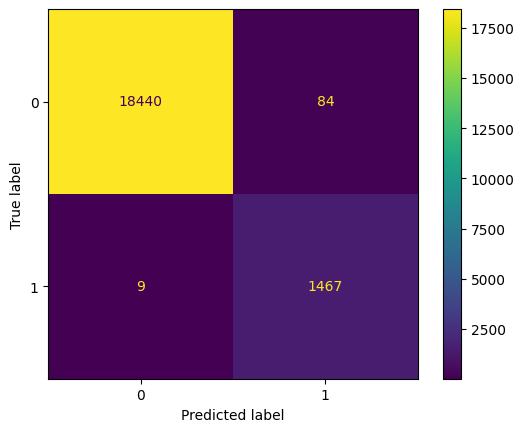

In [71]:
print('Test acc:',gb.score(xtest,ytest))
print('Train acc:',gb.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [72]:
gb_acc=accuracy_score(ytest,ypred)
print('accuracy_score',gb_acc)

accuracy_score 0.99535


# XG BOOST

In [108]:
xgb=XGBClassifier()
xgb.fit(xtrain,ytrain)
ypred=xgb.predict(xtest)

Test acc: 0.9964
Train acc: 0.9987875
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.97      0.99      0.98      1476

    accuracy                           1.00     20000
   macro avg       0.98      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

Confusion matrix:
 [[18472    52]
 [   20  1456]]


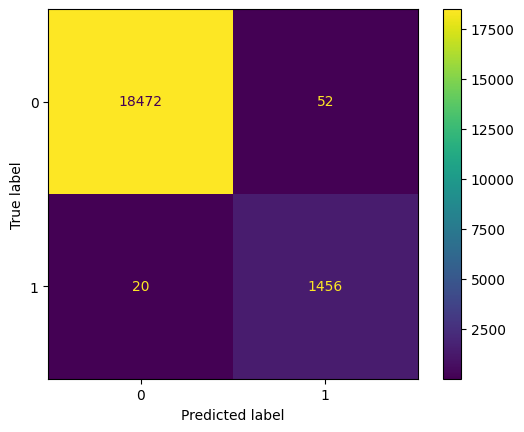

In [109]:
print('Test acc:',xgb.score(xtest,ytest))
print('Train acc:',xgb.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [110]:
xgb_acc=accuracy_score(ytest,ypred)
print('accuracy_score',xgb_acc)

accuracy_score 0.9964


# K NEAREST NEIGHBOR(KNN)

In [111]:
knn=KNeighborsClassifier(n_neighbors=3) 
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

Test acc: 0.9449
Train acc: 0.9723375
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     18524
           1       0.62      0.64      0.63      1476

    accuracy                           0.94     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.95      0.94      0.95     20000

Confusion matrix:
 [[17958   566]
 [  536   940]]


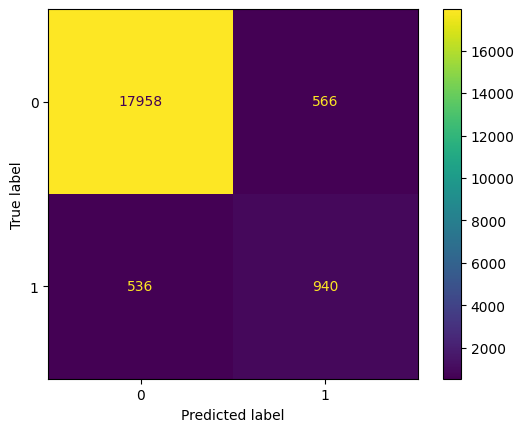

In [112]:
print('Test acc:',knn.score(xtest,ytest))
print('Train acc:',knn.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [113]:
knn_acc=accuracy_score(ytest,ypred)
print('accuracy_score',knn_acc)

accuracy_score 0.9449


# NAIVE BAYES (GaussianNB)

In [114]:
nb=GaussianNB()
nb.fit(xtrain,ytrain)
ypred=nb.predict(xtest)

Test acc: 0.9515
Train acc: 0.94825
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97     18524
           1       0.72      0.57      0.63      1476

    accuracy                           0.95     20000
   macro avg       0.84      0.77      0.80     20000
weighted avg       0.95      0.95      0.95     20000

Confusion matrix:
 [[18195   329]
 [  641   835]]


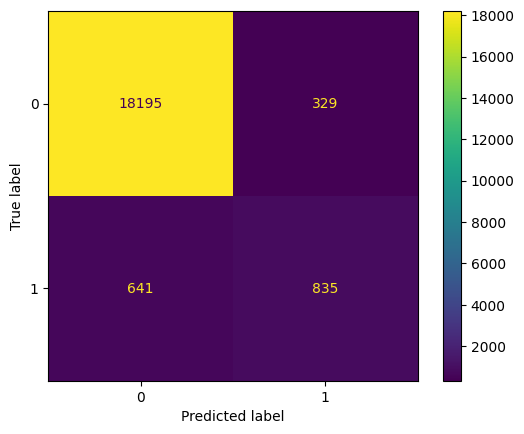

In [115]:
print('Test acc:',nb.score(xtest,ytest))
print('Train acc:',nb.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))
print(ConfusionMatrixDisplay.from_predictions(ytest,ypred))

In [116]:
nb_acc=accuracy_score(ytest,ypred)
print('accuracy_score',nb_acc)

accuracy_score 0.9515


# SVM

In [118]:
from sklearn.svm import SVC
svc=SVC(kernel='linear',C=0.01)
svc.fit(xtrain,ytrain)
ypred=svc.predict(xtest)

In [119]:
print('Test acc:',svc.score(xtest,ytest))
print('Train acc:',svc.score(xtrain,ytrain))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.9262
Train acc: 0.92325
Classification report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96     18524
           1       0.00      0.00      0.00      1476

    accuracy                           0.93     20000
   macro avg       0.46      0.50      0.48     20000
weighted avg       0.86      0.93      0.89     20000

Confusion matrix:
 [[18524     0]
 [ 1476     0]]


In [120]:
svc_acc=accuracy_score(ytest,ypred)
print('accuracy_score',svc_acc)

accuracy_score 0.9262


# Initial Accuracy

In [121]:
tbb=pd.DataFrame()
tbb['Model']=pd.Series(['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier','KNeighborsClassifier','GaussianNB','SVC'])
tbb['Accuracy']=pd.Series([logi_acc,dt_acc,rf_acc,ada_acc,gb_acc,xgb_acc,knn_acc,nb_acc,svc_acc])
tbb

,Model,Accuracy
0,LogisticRegression,0.92490
1,DecisionTreeClassifier,0.95495
2,RandomForestClassifier,0.99720
3,AdaBoostClassifier,0.98810
4,GradientBoostingClassifier,0.99535
5,XGBClassifier,0.99640
6,KNeighborsClassifier,0.94490
7,GaussianNB,0.95150
8,SVC,0.92620


# Over Sampling

In [92]:
data.value_counts('potability')

potability
0    92384
1     7616
Name: count, dtype: int64

In [12]:
from imblearn.over_sampling import SMOTE      # synthetic minority oversampling technique
over=SMOTE(random_state=5)
xtrain_ov,ytrain_ov=over.fit_resample(xtrain,ytrain)
ytrain_ov.value_counts() 

potability
0    73860
1    73860
Name: count, dtype: int64

## LOGISTIC REGRESSION

In [123]:
log=LogisticRegression()
log.fit(xtrain_ov,ytrain_ov)
ypred=log.predict(xtest)
print('Test acc:',log.score(xtest,ytest))
print('Train acc:',log.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.7834
Train acc: 0.8109125372326023
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.78      0.87     18524
           1       0.23      0.82      0.36      1476

    accuracy                           0.78     20000
   macro avg       0.61      0.80      0.61     20000
weighted avg       0.93      0.78      0.83     20000

Confusion matrix:
 [[14451  4073]
 [  259  1217]]


In [124]:
log_acc=accuracy_score(ytest,ypred)
print('accuracy_score',log_acc)

accuracy_score 0.7834


## Decision Tree

In [125]:
dt1=DecisionTreeClassifier(max_depth=5)
dt1.fit(xtrain_ov,ytrain_ov)
ypred=dt1.predict(xtest)

print('Test acc:',dt1.score(xtest,ytest))
print('Train acc:',dt1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.8933
Train acc: 0.9427497969130788
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94     18524
           1       0.41      0.98      0.58      1476

    accuracy                           0.89     20000
   macro avg       0.70      0.93      0.76     20000
weighted avg       0.95      0.89      0.91     20000

Confusion matrix:
 [[16415  2109]
 [   25  1451]]


In [126]:
dt1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',dt1_acc)

accuracy_score 0.8933


## RANDOM FOREST

In [130]:
rf1=RandomForestClassifier(n_estimators=100,random_state=20)
rf1.fit(xtrain_ov,ytrain_ov)
ypred=rf1.predict(xtest)

print('Test acc:',rf1.score(xtest,ytest))
print('Train acc:',rf1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.99655
Train acc: 1.0
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.97      0.99      0.98      1476

    accuracy                           1.00     20000
   macro avg       0.98      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

Confusion matrix:
 [[18475    49]
 [   20  1456]]


In [131]:
rf1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',rf1_acc)

accuracy_score 0.99655


## ADA BOOST

In [132]:
ada1=AdaBoostClassifier(n_estimators=65,learning_rate=.2,random_state=30)
ada1.fit(xtrain_ov,ytrain_ov)
ypred=ada1.predict(xtest)

print('Test acc:',ada1.score(xtest,ytest))
print('Train acc:',ada1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.77125
Train acc: 0.8760966693744923
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.75      0.86     18524
           1       0.24      0.99      0.39      1476

    accuracy                           0.77     20000
   macro avg       0.62      0.87      0.63     20000
weighted avg       0.94      0.77      0.82     20000

Confusion matrix:
 [[13957  4567]
 [    8  1468]]


In [133]:
ada1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',ada1_acc)

accuracy_score 0.77125


## GRADIENT BOOST

In [134]:
gb1=GradientBoostingClassifier(n_estimators=50,learning_rate=0.05,random_state=8)
gb1.fit(xtrain_ov,ytrain_ov)
ypred=gb1.predict(xtest)

print('Test acc:',gb1.score(xtest,ytest))
print('Train acc:',gb1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.93865
Train acc: 0.9669171405361495
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97     18524
           1       0.55      0.99      0.70      1476

    accuracy                           0.94     20000
   macro avg       0.77      0.96      0.84     20000
weighted avg       0.97      0.94      0.95     20000

Confusion matrix:
 [[17311  1213]
 [   14  1462]]


In [135]:
gb1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',gb1_acc)

accuracy_score 0.93865


## XG BOOST

In [136]:
xgb1=XGBClassifier()
xgb1.fit(xtrain_ov,ytrain_ov)
ypred=xgb1.predict(xtest)

print('Test acc:',xgb1.score(xtest,ytest))
print('Train acc:',xgb1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.99435
Train acc: 0.9990319523422692
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.95      0.98      0.96      1476

    accuracy                           0.99     20000
   macro avg       0.97      0.99      0.98     20000
weighted avg       0.99      0.99      0.99     20000

Confusion matrix:
 [[18441    83]
 [   30  1446]]


In [137]:
xgb1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',xgb1_acc)

accuracy_score 0.99435


## K NEAREST NEIGHBOR(KNN)

In [138]:
knn1=KNeighborsClassifier(n_neighbors=3) 
knn1.fit(xtrain_ov,ytrain_ov)
ypred=knn1.predict(xtest)

print('Test acc:',knn1.score(xtest,ytest))
print('Train acc:',knn1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.9023
Train acc: 0.9719469266179258
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.94     18524
           1       0.42      0.86      0.57      1476

    accuracy                           0.90     20000
   macro avg       0.70      0.88      0.76     20000
weighted avg       0.95      0.90      0.92     20000

Confusion matrix:
 [[16773  1751]
 [  203  1273]]


In [139]:
knn1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',knn1_acc)

accuracy_score 0.9023


## NAIVE BAYES (GaussianNB)

In [140]:
nb1=GaussianNB()
nb1.fit(xtrain_ov,ytrain_ov)
ypred=nb1.predict(xtest)

print('Test acc:',nb1.score(xtest,ytest))
print('Train acc:',nb1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.8556
Train acc: 0.9178039534253994
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92     18524
           1       0.34      0.98      0.50      1476

    accuracy                           0.86     20000
   macro avg       0.67      0.91      0.71     20000
weighted avg       0.95      0.86      0.88     20000

Confusion matrix:
 [[15666  2858]
 [   30  1446]]


In [141]:
nb1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',nb1_acc)

accuracy_score 0.8556


## SVM

In [142]:
svc1=SVC(kernel='linear')
svc1.fit(xtrain_ov,ytrain_ov)
ypred=svc1.predict(xtest)

print('Test acc:',svc1.score(xtest,ytest))
print('Train acc:',svc1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.76995
Train acc: 0.8124221500135391
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.76      0.86     18524
           1       0.22      0.85      0.35      1476

    accuracy                           0.77     20000
   macro avg       0.60      0.81      0.61     20000
weighted avg       0.93      0.77      0.82     20000

Confusion matrix:
 [[14149  4375]
 [  226  1250]]


In [143]:
svc1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',svc1_acc)

accuracy_score 0.76995


## ACCURACY AFTER OVERSAMPLING

In [144]:
tbc=pd.DataFrame()
tbc['Model']=pd.Series(['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier','KNeighborsClassifier','GaussianNB','SVC'])
tbc['Accuracy']=pd.Series([logi_acc,dt_acc,rf_acc,ada_acc,gb_acc,xgb_acc,knn_acc,nb_acc,svc_acc])
tbc['Accuracy_oversampling']=pd.Series([log_acc,dt1_acc,rf1_acc,ada1_acc,gb1_acc,xgb1_acc,knn1_acc,nb1_acc,svc1_acc])
tbc

,Model,Accuracy,Accuracy_oversampling
0,LogisticRegression,0.92490,0.78340
1,DecisionTreeClassifier,0.95495,0.89330
2,RandomForestClassifier,0.99720,0.99655
3,AdaBoostClassifier,0.98810,0.77125
4,GradientBoostingClassifier,0.99535,0.93865
5,XGBClassifier,0.99640,0.99435
6,KNeighborsClassifier,0.94490,0.90230
7,GaussianNB,0.95150,0.85560
8,SVC,0.92620,0.76995


# HYPER PARAMETER TUNING

## LOGISTIC REGRESSION

In [176]:
par={'C':[0.01,0.1,0.5,1,10],'penalty':['l1','l2'],'solver':['liblinear','lbfgs','saga']}
logt=GridSearchCV(log,par,cv=10,scoring='accuracy')
logt.fit(xtrain_ov,ytrain_ov)
print(logt.best_params_)
print(logt.best_score_)

{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
0.8108922285404819


In [145]:
log1=LogisticRegression(C=0.01,penalty='l2',solver='lbfgs')

log1.fit(xtrain_ov,ytrain_ov)
ypred=log1.predict(xtest)
print('Test acc:',log1.score(xtest,ytest))
print('Train acc:',log1.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.78315
Train acc: 0.8108719198483617
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.78      0.87     18524
           1       0.23      0.82      0.36      1476

    accuracy                           0.78     20000
   macro avg       0.61      0.80      0.61     20000
weighted avg       0.93      0.78      0.83     20000

Confusion matrix:
 [[14446  4078]
 [  259  1217]]


In [146]:
log1_acc=accuracy_score(ytest,ypred)
print('accuracy_score',log1_acc)

accuracy_score 0.78315


## DECISION TREE

In [179]:
par={'max_depth':[3,5,10],'criterion':['gini','entropy'],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4]}
dtt=GridSearchCV(dt1,par,cv=5,scoring='accuracy')
dtt.fit(xtrain_ov,ytrain_ov) 
print(dtt.best_params_)
print(dtt.best_score_)

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
0.9927701056051991


In [147]:
dt2=DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_leaf=2,min_samples_split=10)
dt2.fit(xtrain_ov,ytrain_ov)
ypred=dt2.predict(xtest)

print('Test acc:',dt2.score(xtest,ytest))
print('Train acc:',dt2.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.98795
Train acc: 0.9934267533170864
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     18524
           1       0.86      1.00      0.92      1476

    accuracy                           0.99     20000
   macro avg       0.93      0.99      0.96     20000
weighted avg       0.99      0.99      0.99     20000

Confusion matrix:
 [[18286   238]
 [    3  1473]]


In [148]:
dt2_acc=accuracy_score(ytest,ypred)
print('accuracy_score',dt2_acc)

accuracy_score 0.98795


## RANDOM FOREST

In [182]:
par={'n_estimators':[20,30,50],'max_depth':[None,10,20],'max_features':['sqrt']}
rft=GridSearchCV(rf1,par,cv=5,scoring='accuracy')
rft.fit(xtrain_ov,ytrain_ov)
print(rft.best_params_)
print(rft.best_score_)

{'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 50}
0.9975900352017331


In [149]:
rf2=RandomForestClassifier(max_depth=20,max_features='sqrt',n_estimators=50,random_state=20)
rf2.fit(xtrain_ov,ytrain_ov)
ypred=rf2.predict(xtest)

print('Test acc:',rf2.score(xtest,ytest))
print('Train acc:',rf2.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.997
Train acc: 0.9987950176008665
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.97      0.99      0.98      1476

    accuracy                           1.00     20000
   macro avg       0.98      1.00      0.99     20000
weighted avg       1.00      1.00      1.00     20000

Confusion matrix:
 [[18474    50]
 [   10  1466]]


In [150]:
rf2_acc=accuracy_score(ytest,ypred)
print('accuracy_score',rf2_acc)

accuracy_score 0.997


## ADA BOOST

In [186]:
par={'n_estimators':[50,100,150],'learning_rate':[0.01,0.05,0.1,0.5]}
adt=GridSearchCV(ada1,par,cv=5,scoring='accuracy',n_jobs=-1)
adt.fit(xtrain_ov,ytrain_ov)
print(adt.best_params_)
print(adt.best_score_)

{'learning_rate': 0.5, 'n_estimators': 150}
0.9659558624424587


In [151]:
ada2=AdaBoostClassifier(n_estimators=150,learning_rate=0.5,random_state=30)
ada2.fit(xtrain_ov,ytrain_ov)
ypred=ada2.predict(xtest)

print('Test acc:',ada2.score(xtest,ytest))
print('Train acc:',ada2.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.9383
Train acc: 0.9663214189006228
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97     18524
           1       0.54      1.00      0.71      1476

    accuracy                           0.94     20000
   macro avg       0.77      0.97      0.84     20000
weighted avg       0.97      0.94      0.95     20000

Confusion matrix:
 [[17290  1234]
 [    0  1476]]


In [152]:
ada2_acc=accuracy_score(ytest,ypred)
print('accuracy_score',ada2_acc)

accuracy_score 0.9383


## GRADIENT BOOST

In [191]:
par={'n_estimators':[100,200],'max_depth':[3,4],'learning_rate':[0.01,0.05,0.1]}
gbt=GridSearchCV(gb1,par,cv=3,scoring='accuracy',n_jobs=-1)
gbt.fit(xtrain_ov,ytrain_ov)
print(gbt.best_params_)
print(gbt.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
0.9985310046033035


In [154]:
gb2=GradientBoostingClassifier(n_estimators=200,learning_rate=0.1,max_depth=3,random_state=8)
gb2.fit(xtrain_ov,ytrain_ov)
ypred=gb2.predict(xtest)

print('Test acc:',gb2.score(xtest,ytest))
print('Train acc:',gb2.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.99735
Train acc: 0.9987814784727863
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.97      1.00      0.98      1476

    accuracy                           1.00     20000
   macro avg       0.98      1.00      0.99     20000
weighted avg       1.00      1.00      1.00     20000

Confusion matrix:
 [[18471    53]
 [    0  1476]]


In [155]:
gb2_acc=accuracy_score(ytest,ypred)
print('accuracy_score',gb2_acc)

accuracy_score 0.99735


## XG BOOST

In [195]:
param={"max_depth":[3,6,10],"learning_rate":[0.01,0.1,0.3],"n_estimators":[100,200],"subsample":[0.7,1],"colsample_bytree":[0.7,1]}
xgt=GridSearchCV(xgb1,param,cv=5,scoring="accuracy") 
xgt.fit(xtrain_ov,ytrain_ov)
print(xgt.best_params_)
print(xgt.best_score_)

{'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.7}
0.9971229352829678


In [156]:
xgb2=XGBClassifier(max_depth=10,learning_rate=0.3,n_estimators=200,colsample_bytree=0.7,subsample=0.7,random_state=20)
xgb2.fit(xtrain_ov,ytrain_ov)
ypred=xgb2.predict(xtest)

print('Test acc:',xgb2.score(xtest,ytest))
print('Train acc:',xgb2.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.9947
Train acc: 1.0
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18524
           1       0.95      0.98      0.96      1476

    accuracy                           0.99     20000
   macro avg       0.98      0.99      0.98     20000
weighted avg       0.99      0.99      0.99     20000

Confusion matrix:
 [[18451    73]
 [   33  1443]]


In [157]:
xgb2_acc=accuracy_score(ytest,ypred)
print('accuracy_score',xgb2_acc)

accuracy_score 0.9947


## KNN

In [204]:
knn=KNeighborsClassifier()
par={'n_neighbors':[2,3,6,7,9],'weights':['uniform','distance'],'metric':['euclidean','manhattan']}
knt=GridSearchCV(knn,par,cv=3,scoring='accuracy',n_jobs=-1)
knt.fit(xtrain_ov,ytrain_ov)
print(knt.best_params_)
print(knt.best_score_) 

{'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'uniform'}
0.965353371242892


In [158]:
knn2=KNeighborsClassifier(n_neighbors=2,metric='euclidean',weights='uniform') 
knn2.fit(xtrain_ov,ytrain_ov)
ypred=knn2.predict(xtest)

print('Test acc:',knn2.score(xtest,ytest))
print('Train acc:',knn2.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.9276
Train acc: 0.9999864608719199
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96     18524
           1       0.51      0.70      0.59      1476

    accuracy                           0.93     20000
   macro avg       0.74      0.82      0.77     20000
weighted avg       0.94      0.93      0.93     20000

Confusion matrix:
 [[17518  1006]
 [  442  1034]]


In [159]:
knn2_acc=accuracy_score(ytest,ypred)
print('accuracy_score',knn2_acc)

accuracy_score 0.9276


## NAIVE BAYES

In [209]:
gnb=GaussianNB()
par={'var_smoothing':[1e-9,1e-8,1e-7,1e-6,1e-5,1e-4]}
nbt=GridSearchCV(gnb,par,cv=5,scoring='accuracy',n_jobs=-1)
nbt.fit(xtrain_ov,ytrain_ov)
print(nbt.best_params_)
print(nbt.best_score_)

{'var_smoothing': 1e-09}
0.9177565664771189


In [160]:
nb2=GaussianNB(var_smoothing=1e-09)
nb2.fit(xtrain_ov,ytrain_ov)
ypred=nb2.predict(xtest)

print('Test acc:',nb2.score(xtest,ytest))
print('Train acc:',nb2.score(xtrain_ov,ytrain_ov))
print('Classification report:\n',classification_report(ytest,ypred))
print('Confusion matrix:\n',confusion_matrix(ytest,ypred))

Test acc: 0.8556
Train acc: 0.9178039534253994
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92     18524
           1       0.34      0.98      0.50      1476

    accuracy                           0.86     20000
   macro avg       0.67      0.91      0.71     20000
weighted avg       0.95      0.86      0.88     20000

Confusion matrix:
 [[15666  2858]
 [   30  1446]]


In [161]:
nb2_acc=accuracy_score(ytest,ypred)
print('accuracy_score',nb2_acc)

accuracy_score 0.8556


## SVC

In [216]:
svc=SVC()
par={'C':[1,10,20],'kernel':['linear','rbf'],'gamma':['scale','auto']}
svcg=GridSearchCV(svc,par,cv=3,n_jobs=-1,scoring='accuracy')
svcg.fit(xtrain_ov,ytrain_ov)
print(svcg.best_params_)
print(svcg.best_score_)

KeyboardInterrupt: 

In [162]:
tb=pd.DataFrame()
tb['Model']=pd.Series(['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier','KNeighborsClassifier','GaussianNB','SVC'])
tb['Accuracy']=pd.Series([logi_acc,dt_acc,rf_acc,ada_acc,gb_acc,xgb_acc,knn_acc,nb_acc,svc_acc])
tb['Accuracy_oversampling']=pd.Series([log_acc,dt1_acc,rf1_acc,ada1_acc,gb1_acc,xgb1_acc,knn1_acc,nb1_acc,svc1_acc])
tb['Accuracy after tuning']=pd.Series([log1_acc,dt2_acc,rf2_acc,ada2_acc,gb2_acc,xgb2_acc,knn2_acc,nb2_acc])
tb

,Model,Accuracy,Accuracy_oversampling,Accuracy after tuning
0,LogisticRegression,0.92490,0.78340,0.78315
1,DecisionTreeClassifier,0.95495,0.89330,0.98795
2,RandomForestClassifier,0.99720,0.99655,0.99700
3,AdaBoostClassifier,0.98810,0.77125,0.93830
4,GradientBoostingClassifier,0.99535,0.93865,0.99735
5,XGBClassifier,0.99640,0.99435,0.99470
6,KNeighborsClassifier,0.94490,0.90230,0.92760
7,GaussianNB,0.95150,0.85560,0.85560
8,SVC,0.92620,0.76995,NaN


### TEST AND TRAIN ACCURACY

In [163]:
logtrain=log1.score(xtrain_ov,ytrain_ov)
dttrain=dt2.score(xtrain_ov,ytrain_ov)
rftrain=rf2.score(xtrain_ov,ytrain_ov)
adatrain=ada2.score(xtrain_ov,ytrain_ov)
gbtrain=gb2.score(xtrain_ov,ytrain_ov)
xgbtrain=xgb2.score(xtrain_ov,ytrain_ov)
knntrain=knn2.score(xtrain_ov,ytrain_ov)
nbtrain=nb2.score(xtrain_ov,ytrain_ov)
svctrain=svc1.score(xtrain_ov,ytrain_ov)

In [164]:
tb1=pd.DataFrame()
tb1['Model']=pd.Series(['LogisticRegression','DecisionTreeClassifier','RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier','XGBClassifier','KNeighborsClassifier','GaussianNB','SVC'])
tb1['Test Accuracy']=pd.Series([log1_acc,dt2_acc,rf2_acc,ada2_acc,gb2_acc,xgb2_acc,knn2_acc,nb2_acc,svc1_acc])
tb1['Train Accuracy']=pd.Series([logtrain,dttrain,rftrain,adatrain,gbtrain,xgbtrain,knntrain,nbtrain,svctrain])
tb1

,Model,Test Accuracy,Train Accuracy
0,LogisticRegression,0.78315,0.810872
1,DecisionTreeClassifier,0.98795,0.993427
2,RandomForestClassifier,0.99700,0.998795
3,AdaBoostClassifier,0.93830,0.966321
4,GradientBoostingClassifier,0.99735,0.998781
5,XGBClassifier,0.99470,1.000000
6,KNeighborsClassifier,0.92760,0.999986
7,GaussianNB,0.85560,0.917804
8,SVC,0.76995,0.812422


In [165]:
tb1.sort_values(by='Test Accuracy',ascending=False)

,Model,Test Accuracy,Train Accuracy
4,GradientBoostingClassifier,0.99735,0.998781
2,RandomForestClassifier,0.99700,0.998795
5,XGBClassifier,0.99470,1.000000
1,DecisionTreeClassifier,0.98795,0.993427
3,AdaBoostClassifier,0.93830,0.966321
6,KNeighborsClassifier,0.92760,0.999986
7,GaussianNB,0.85560,0.917804
0,LogisticRegression,0.78315,0.810872
8,SVC,0.76995,0.812422


## Saving

In [14]:
import joblib

joblib.dump(gb2,'C:/Users/muhmd/gb_model.pkl')
joblib.dump(sc,'C:/Users/muhmd/scaler_water.pkl')

['C:/Users/muhmd/scaler_water.pkl']

In [45]:
data.sort_values(by='potability',ascending=False)

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
29124,6.25,305.45,182.84000,3.59,34.15,180.080,5.84,41.84,4.82,1
30724,7.39,236.24,151.59000,3.03,235.11,620.920,6.19,33.58,1.08,1
99986,7.77,146.93,267.30000,0.19,158.16,1473.030,9.60,96.66,2.77,1
18928,7.91,182.96,119.52000,1.06,185.33,1709.290,8.79,86.87,4.70,1
43534,6.15,54.36,136.00000,0.52,114.30,1726.470,6.97,22.93,2.90,1
...,...,...,...,...,...,...,...,...,...,...
99979,6.45,116.75,145.19000,3.52,194.49,2475.200,5.47,93.63,0.71,0
99980,6.04,751.64,694.75375,0.63,317.59,2513.660,4.91,14.20,3.07,0
99981,5.07,3.59,95.33000,2.65,190.30,2195.550,0.24,130.12,0.50,0
99982,6.98,209.49,270.15500,2.70,341.70,1069.620,9.61,7.61,2.84,0
